<a href="https://colab.research.google.com/github/sansharif/AI-Knowledge-DRI-EDIA-Champion-Pilot-Program/blob/main/CPRA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:

import pandas as pd
import zipfile
import io
from google.colab import files

# Upload downloaded NASA FIRMS files
uploaded = files.upload()

dataframes = []

for filename, content in uploaded.items():

    if filename.lower().endswith(".zip"):
        print(f"\nOpening ZIP: {filename}")

        with zipfile.ZipFile(io.BytesIO(content)) as z:
            csv_files = [
                name for name in z.namelist()
                if name.lower().endswith(".csv")
                and not name.startswith("__MACOSX")
            ]

            print("CSV files found:", csv_files)

            for csv_name in csv_files:
                with z.open(csv_name) as f:
                    df = pd.read_csv(f)

                df["source_file"] = filename
                df["source_csv"] = csv_name

                dataframes.append(df)
                print(f"{csv_name}: {len(df)} records")

    elif filename.lower().endswith(".csv"):
        df = pd.read_csv(io.BytesIO(content))
        df["source_file"] = filename
        dataframes.append(df)
        print(f"{filename}: {len(df)} records")

if not dataframes:
    raise ValueError("No CSV files found. Check ZIP contents.")

# Combine all wildfire records
wildfire_df = pd.concat(
    dataframes,
    ignore_index=True
)

print("\nTotal observations:", len(wildfire_df))

print("\nAvailable columns:")
print(wildfire_df.columns.tolist())

print("\nFirst five records:")
display(wildfire_df.head())



Saving DL_FIRE_J1V-C2_819559.zip to DL_FIRE_J1V-C2_819559 (2).zip
Saving DL_FIRE_SV-C2_819561.zip to DL_FIRE_SV-C2_819561.zip

Opening ZIP: DL_FIRE_J1V-C2_819559 (2).zip
CSV files found: ['fire_archive_J1V-C2_819559.csv']
fire_archive_J1V-C2_819559.csv: 361325 records

Opening ZIP: DL_FIRE_SV-C2_819561.zip
CSV files found: ['fire_archive_SV-C2_819561.csv']
fire_archive_SV-C2_819561.csv: 387251 records

Total observations: 748576

Available columns:
['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_t31', 'frp', 'daynight', 'type', 'source_file', 'source_csv']

First five records:


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,source_file,source_csv
0,49.15323,-115.09627,305.30,0.42,0.61,2023-01-01,1048,N20,VIIRS,n,2,268.76,2.00,N,0,DL_FIRE_J1V-C2_819559 (2).zip,fire_archive_J1V-C2_819559.csv
1,50.91633,-120.85757,300.19,0.43,0.46,2023-01-01,1048,N20,VIIRS,n,2,264.02,1.64,N,0,DL_FIRE_J1V-C2_819559 (2).zip,fire_archive_J1V-C2_819559.csv
2,49.09225,-115.07672,301.94,0.42,0.61,2023-01-01,1048,N20,VIIRS,n,2,268.20,0.60,N,0,DL_FIRE_J1V-C2_819559 (2).zip,fire_archive_J1V-C2_819559.csv
3,49.54919,-114.98434,332.57,0.42,0.37,2023-01-01,2036,N20,VIIRS,n,2,270.67,5.32,D,0,DL_FIRE_J1V-C2_819559 (2).zip,fire_archive_J1V-C2_819559.csv
4,56.38467,-121.02537,297.74,0.41,0.37,2023-01-03,1009,N20,VIIRS,n,2,265.61,0.93,N,0,DL_FIRE_J1V-C2_819559 (2).zip,fire_archive_J1V-C2_819559.csv


In [4]:

# Convert acquisition dates to datetime
wildfire_df["acq_date"] = pd.to_datetime(
    wildfire_df["acq_date"],
    errors="coerce"
)

print("Total observations:", len(wildfire_df))

print("\nAvailable years:")
print(
    wildfire_df["acq_date"]
    .dt.year.value_counts()
    .sort_index()
)

print("\nDate range:")
print("Start:", wildfire_df["acq_date"].min())
print("End:", wildfire_df["acq_date"].max())

print("\nCoordinate ranges:")
print(
    wildfire_df[
        ["latitude", "longitude"]
    ].describe()
)


Total observations: 748576

Available years:
acq_date
2023    748576
Name: count, dtype: int64

Date range:
Start: 2023-01-01 00:00:00
End: 2023-12-31 00:00:00

Coordinate ranges:
            latitude      longitude
count  748576.000000  748576.000000
mean       56.258510    -122.386112
std         3.112902       2.593414
min        48.382540    -134.320650
25%        53.736595    -124.467635
50%        57.447090    -121.623985
75%        58.860732    -120.552738
max        60.000030    -114.528380


In [5]:

# Filter wildfire observations for 2023
wildfire_2023 = wildfire_df[
    wildfire_df["acq_date"].dt.year == 2023
].copy()

print("2023 observations:", len(wildfire_2023))

if wildfire_2023.empty:
    print(
        "No 2023 records found. "
        "Check the downloaded archive's date range."
    )
else:
    display(wildfire_2023.head())


2023 observations: 748576


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,source_file,source_csv
0,49.15323,-115.09627,305.30,0.42,0.61,2023-01-01,1048,N20,VIIRS,n,2,268.76,2.00,N,0,DL_FIRE_J1V-C2_819559 (2).zip,fire_archive_J1V-C2_819559.csv
1,50.91633,-120.85757,300.19,0.43,0.46,2023-01-01,1048,N20,VIIRS,n,2,264.02,1.64,N,0,DL_FIRE_J1V-C2_819559 (2).zip,fire_archive_J1V-C2_819559.csv
2,49.09225,-115.07672,301.94,0.42,0.61,2023-01-01,1048,N20,VIIRS,n,2,268.20,0.60,N,0,DL_FIRE_J1V-C2_819559 (2).zip,fire_archive_J1V-C2_819559.csv
3,49.54919,-114.98434,332.57,0.42,0.37,2023-01-01,2036,N20,VIIRS,n,2,270.67,5.32,D,0,DL_FIRE_J1V-C2_819559 (2).zip,fire_archive_J1V-C2_819559.csv
4,56.38467,-121.02537,297.74,0.41,0.37,2023-01-03,1009,N20,VIIRS,n,2,265.61,0.93,N,0,DL_FIRE_J1V-C2_819559 (2).zip,fire_archive_J1V-C2_819559.csv


In [6]:

# Approximate BC bounding box
# This is preliminary, not an official provincial boundary.

bc_wildfire = wildfire_2023[
    (wildfire_2023["latitude"] >= 48.0) &
    (wildfire_2023["latitude"] <= 60.1) &
    (wildfire_2023["longitude"] >= -139.1) &
    (wildfire_2023["longitude"] <= -114.0)
].copy()

print("2023 BC-region fire detections:", len(bc_wildfire))

display(bc_wildfire.head())


2023 BC-region fire detections: 748576


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,source_file,source_csv
0,49.15323,-115.09627,305.30,0.42,0.61,2023-01-01,1048,N20,VIIRS,n,2,268.76,2.00,N,0,DL_FIRE_J1V-C2_819559 (2).zip,fire_archive_J1V-C2_819559.csv
1,50.91633,-120.85757,300.19,0.43,0.46,2023-01-01,1048,N20,VIIRS,n,2,264.02,1.64,N,0,DL_FIRE_J1V-C2_819559 (2).zip,fire_archive_J1V-C2_819559.csv
2,49.09225,-115.07672,301.94,0.42,0.61,2023-01-01,1048,N20,VIIRS,n,2,268.20,0.60,N,0,DL_FIRE_J1V-C2_819559 (2).zip,fire_archive_J1V-C2_819559.csv
3,49.54919,-114.98434,332.57,0.42,0.37,2023-01-01,2036,N20,VIIRS,n,2,270.67,5.32,D,0,DL_FIRE_J1V-C2_819559 (2).zip,fire_archive_J1V-C2_819559.csv
4,56.38467,-121.02537,297.74,0.41,0.37,2023-01-03,1009,N20,VIIRS,n,2,265.61,0.93,N,0,DL_FIRE_J1V-C2_819559 (2).zip,fire_archive_J1V-C2_819559.csv


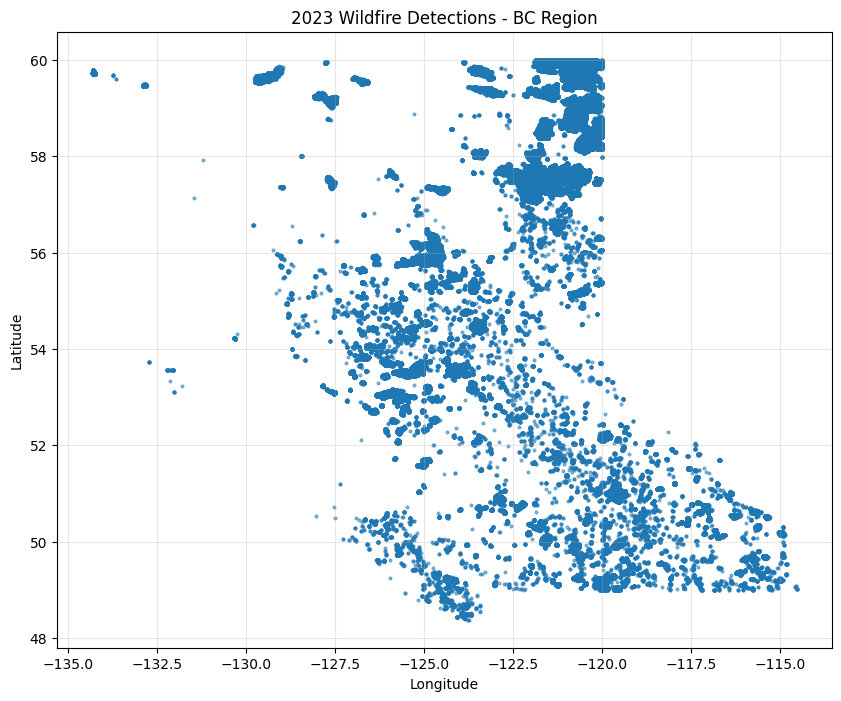

In [7]:

import matplotlib.pyplot as plt

if not bc_wildfire.empty:
    plt.figure(figsize=(10, 8))

    plt.scatter(
        bc_wildfire["longitude"],
        bc_wildfire["latitude"],
        s=4,
        alpha=0.5
    )

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("2023 Wildfire Detections - BC Region")
    plt.grid(alpha=0.3)

    plt.show()
else:
    print("No observations to visualize.")


In [8]:

if bc_wildfire.empty:
    print("No records available to save.")
else:
    output_file = "BC_Wildfire_2023_Preliminary.csv"

    bc_wildfire.to_csv(
        output_file,
        index=False
    )

    print("Saved:", output_file)
    print("Records:", len(bc_wildfire))


Saved: BC_Wildfire_2023_Preliminary.csv
Records: 748576


In [9]:

# Filter 2023 wildfire detections
# using an approximate BC bounding box

bc_wildfire = wildfire_2023[
    (wildfire_2023["latitude"] >= 48.0) &
    (wildfire_2023["latitude"] <= 60.1) &
    (wildfire_2023["longitude"] >= -139.1) &
    (wildfire_2023["longitude"] <= -114.0)
].copy()

print("Total 2023 observations:", len(wildfire_2023))
print("BC-region observations:", len(bc_wildfire))

print("\nFirst five records:")
display(bc_wildfire.head())


Total 2023 observations: 748576
BC-region observations: 748576

First five records:


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,source_file,source_csv
0,49.15323,-115.09627,305.30,0.42,0.61,2023-01-01,1048,N20,VIIRS,n,2,268.76,2.00,N,0,DL_FIRE_J1V-C2_819559 (2).zip,fire_archive_J1V-C2_819559.csv
1,50.91633,-120.85757,300.19,0.43,0.46,2023-01-01,1048,N20,VIIRS,n,2,264.02,1.64,N,0,DL_FIRE_J1V-C2_819559 (2).zip,fire_archive_J1V-C2_819559.csv
2,49.09225,-115.07672,301.94,0.42,0.61,2023-01-01,1048,N20,VIIRS,n,2,268.20,0.60,N,0,DL_FIRE_J1V-C2_819559 (2).zip,fire_archive_J1V-C2_819559.csv
3,49.54919,-114.98434,332.57,0.42,0.37,2023-01-01,2036,N20,VIIRS,n,2,270.67,5.32,D,0,DL_FIRE_J1V-C2_819559 (2).zip,fire_archive_J1V-C2_819559.csv
4,56.38467,-121.02537,297.74,0.41,0.37,2023-01-03,1009,N20,VIIRS,n,2,265.61,0.93,N,0,DL_FIRE_J1V-C2_819559 (2).zip,fire_archive_J1V-C2_819559.csv


In [10]:

print("=== GEOGRAPHICAL VERIFICATION ===")

print("\nLatitude range:")
print("Minimum:", bc_wildfire["latitude"].min())
print("Maximum:", bc_wildfire["latitude"].max())

print("\nLongitude range:")
print("Minimum:", bc_wildfire["longitude"].min())
print("Maximum:", bc_wildfire["longitude"].max())

print("\nRecords by satellite/source:")
print(bc_wildfire["source_file"].value_counts())

print("\nRecords by month:")
print(
    bc_wildfire["acq_date"]
    .dt.month.value_counts()
    .sort_index()
)


=== GEOGRAPHICAL VERIFICATION ===

Latitude range:
Minimum: 48.38254
Maximum: 60.00003

Longitude range:
Minimum: -134.32065
Maximum: -114.52838

Records by satellite/source:
source_file
DL_FIRE_SV-C2_819561.zip         387251
DL_FIRE_J1V-C2_819559 (2).zip    361325
Name: count, dtype: int64

Records by month:
acq_date
1        949
2        808
3        658
4       1018
5      47395
6      95514
7     154797
8     177706
9     252478
10      7132
11      8525
12      1596
Name: count, dtype: int64


In [12]:

print("=== GEOGRAPHICAL VERIFICATION ===")

print("\nLatitude range:")
print("Minimum:", bc_wildfire["latitude"].min())
print("Maximum:", bc_wildfire["latitude"].max())

print("\nLongitude range:")
print("Minimum:", bc_wildfire["longitude"].min())
print("Maximum:", bc_wildfire["longitude"].max())

print("\nRecords by satellite/source:")
print(bc_wildfire["source_file"].value_counts())

print("\nRecords by month:")
print(
    bc_wildfire["acq_date"]
    .dt.month.value_counts()
    .sort_index()
)


=== GEOGRAPHICAL VERIFICATION ===

Latitude range:
Minimum: 48.38254
Maximum: 60.00003

Longitude range:
Minimum: -134.32065
Maximum: -114.52838

Records by satellite/source:
source_file
DL_FIRE_SV-C2_819561.zip         387251
DL_FIRE_J1V-C2_819559 (2).zip    361325
Name: count, dtype: int64

Records by month:
acq_date
1        949
2        808
3        658
4       1018
5      47395
6      95514
7     154797
8     177706
9     252478
10      7132
11      8525
12      1596
Name: count, dtype: int64


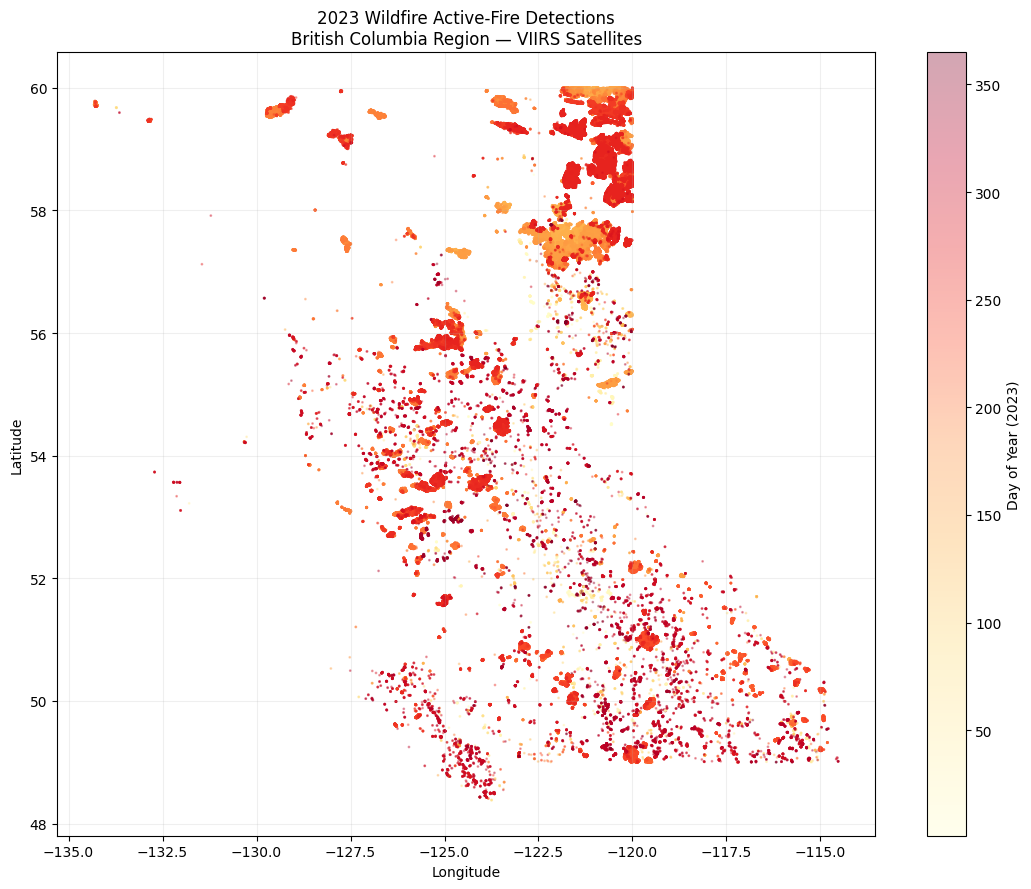

In [13]:

import matplotlib.pyplot as plt

# Plot all 2023 BC-region fire detections
plt.figure(figsize=(11, 9))

scatter = plt.scatter(
    bc_wildfire["longitude"],
    bc_wildfire["latitude"],
    c=bc_wildfire["acq_date"].dt.dayofyear,
    cmap="YlOrRd",
    s=1,
    alpha=0.35,
    rasterized=True
)

plt.colorbar(
    scatter,
    label="Day of Year (2023)"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "2023 Wildfire Active-Fire Detections\n"
    "British Columbia Region — VIIRS Satellites"
)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [14]:

import geopandas as gpd
import zipfile
import os
from google.colab import files

# Install geospatial libraries
!pip -q install geopandas pyogrio

# Upload the downloaded evacuation ZIP
uploaded = files.upload()

# Identify the uploaded ZIP
zip_files = [
    name for name in uploaded
    if name.lower().endswith(".zip")
]

if not zip_files:
    raise ValueError("Please upload the evacuation ZIP file.")

zip_name = zip_files[0]

# Inspect archive contents
with zipfile.ZipFile(zip_name, "r") as z:
    archive_files = z.namelist()

print("Uploaded ZIP:", zip_name)
print("\nFiles inside ZIP:")

for name in archive_files:
    print(name)

print("\nShapefiles found:")
shp_files = [
    name for name in archive_files
    if name.lower().endswith(".shp")
]

print(shp_files)


Saving BCGW_02001F02_1791479729690_4892.zip to BCGW_02001F02_1791479729690_4892.zip
Uploaded ZIP: BCGW_02001F02_1791479729690_4892.zip

Files inside ZIP:
Contents of Order.txt
EMRG_ORDER_ALERT_AREAS_HIST_SP/EMRGORDERA_polygon.cpg
EMRG_ORDER_ALERT_AREAS_HIST_SP/EMRGORDERA_polygon.dbf
EMRG_ORDER_ALERT_AREAS_HIST_SP/EMRGORDERA_polygon.prj
EMRG_ORDER_ALERT_AREAS_HIST_SP/EMRGORDERA_polygon.shp
EMRG_ORDER_ALERT_AREAS_HIST_SP/EMRGORDERA_polygon.shx
licence.txt
README.txt
WHSE_HUMAN_CULTURAL_ECONOMIC.EMRG_ORDER_ALERT_AREAS_HIST_SP_metadata.json
WHSE_HUMAN_CULTURAL_ECONOMIC.EMRG_ORDER_ALERT_AREAS_HIST_SP_metadata.html

Shapefiles found:
['EMRG_ORDER_ALERT_AREAS_HIST_SP/EMRGORDERA_polygon.shp']


In [15]:

import tempfile

# Extract into a temporary folder
extract_dir = tempfile.mkdtemp(
    prefix="bc_evacuation_"
)

with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall(extract_dir)

# Find shapefiles
shapefile_paths = []

for root, dirs, filenames in os.walk(extract_dir):
    for filename in filenames:
        if filename.lower().endswith(".shp"):
            shapefile_paths.append(
                os.path.join(root, filename)
            )

print("Shapefiles found:")
print(shapefile_paths)

if not shapefile_paths:
    raise ValueError("No shapefile found in archive.")

# Read the first shapefile
evacuation_df = gpd.read_file(
    shapefile_paths[0]
)

print("\nTotal evacuation records:", len(evacuation_df))

print("\nAvailable columns:")
print(evacuation_df.columns.tolist())

print("\nCoordinate reference system:")
print(evacuation_df.crs)

print("\nFirst five records:")
display(evacuation_df.head())


Shapefiles found:
['/tmp/bc_evacuation_9kye0ui4/EMRG_ORDER_ALERT_AREAS_HIST_SP/EMRGORDERA_polygon.shp']

Total evacuation records: 7137

Available columns:
['SYSID', 'EVENT_NAME', 'EVENT_NUM', 'EVENT_TYPE', 'EVENT_DT', 'DOC_NAME', 'OA_STATUS', 'ISS_AGENCY', 'PREOC_CD', 'RD_CODE', 'MUNI_NAME', 'INDN_BND_M', 'ORDER1_DT', 'ORDER2_DT', 'ORDER3_DT', 'ORDER4_DT', 'ORDER5_DT', 'ALERT1_DT', 'ALERT2_DT', 'ALERT3_DT', 'ALERT4_DT', 'ALERT5_DT', 'TE+DT', 'ALL_CLR_DT', 'MLT_SRCD_N', 'MLT_SRCD_S', 'FEAT_AREA', 'FEAT_LEN', 'SHAPE', 'OBJECTID', 'geometry']

Coordinate reference system:
EPSG:3005

First five records:


,SYSID,EVENT_NAME,EVENT_NUM,EVENT_TYPE,EVENT_DT,DOC_NAME,OA_STATUS,ISS_AGENCY,PREOC_CD,RD_CODE,...,ALERT5_DT,TE+DT,ALL_CLR_DT,MLT_SRCD_N,MLT_SRCD_S,FEAT_AREA,FEAT_LEN,SHAPE,OBJECTID,geometry
0,32,67351 Tunnels Rd Flooding,None,Flood,20211128120000,67351 Tunnels Rd Flooding,All Clear,District of Hope,SWE,FVRD,...,None,None,20211222120000,0.0,1.0,9.087792e+04,1351.3889,NaN,10976424.0,"POLYGON ((1336742.372 495899.935, 1336730.289 ..."
1,33,"Othello Road, FVRD Electoral Area B",None,Flood,20211128120000,Othello Road second expansion,All Clear,Fraser Valley Regional District,SWE,FVRD,...,None,None,20211222120000,0.0,2.0,2.399250e+05,2301.7829,NaN,10976425.0,"POLYGON ((1338766.039 496280.383, 1339581.963 ..."
2,34,Sumas Prairie,None,Flood,20211114120000,Sumas Prairie - North Parallel Road,All Clear,City of Abbotsford,SWE,FVRD,...,None,None,20211223120000,0.0,3.0,4.233024e+04,1721.0056,NaN,10976426.0,"POLYGON ((1275940.613 454015.488, 1275998.391 ..."
3,35,Sumas Prairie,None,Flood,20211114120000,Sumas Prairie,All Clear,City of Abbotsford,SWE,FVRD,...,None,None,20211223120000,0.0,1.0,5.652500e+04,1250.8954,NaN,10976427.0,"POLYGON ((1274375.954 450162.551, 1273816.841 ..."
4,36,Sumas Prairie,None,Flood,20211114120000,Sumas Prairie,All Clear,City of Abbotsford,SWE,FVRD,...,None,None,20211223120000,710.0,236.0,1.676438e+07,25265.8212,NaN,10976428.0,"POLYGON ((1286118 457262.933, 1286380.141 4572..."


In [16]:

print("=== EVACUATION DATASET SUMMARY ===")

print("\nTotal records:")
print(len(evacuation_df))

print("\nColumn names:")
for col in evacuation_df.columns:
    print(col)

print("\nCoordinate reference system:")
print(evacuation_df.crs)

print("\nFirst 3 records:")
display(evacuation_df.drop(columns="geometry").head(3))


=== EVACUATION DATASET SUMMARY ===

Total records:
7137

Column names:
SYSID
EVENT_NAME
EVENT_NUM
EVENT_TYPE
EVENT_DT
DOC_NAME
OA_STATUS
ISS_AGENCY
PREOC_CD
RD_CODE
MUNI_NAME
INDN_BND_M
ORDER1_DT
ORDER2_DT
ORDER3_DT
ORDER4_DT
ORDER5_DT
ALERT1_DT
ALERT2_DT
ALERT3_DT
ALERT4_DT
ALERT5_DT
TE+DT
ALL_CLR_DT
MLT_SRCD_N
MLT_SRCD_S
FEAT_AREA
FEAT_LEN
SHAPE
OBJECTID
geometry

Coordinate reference system:
EPSG:3005

First 3 records:


,SYSID,EVENT_NAME,EVENT_NUM,EVENT_TYPE,EVENT_DT,DOC_NAME,OA_STATUS,ISS_AGENCY,PREOC_CD,RD_CODE,...,ALERT4_DT,ALERT5_DT,TE+DT,ALL_CLR_DT,MLT_SRCD_N,MLT_SRCD_S,FEAT_AREA,FEAT_LEN,SHAPE,OBJECTID
0,32,67351 Tunnels Rd Flooding,None,Flood,20211128120000,67351 Tunnels Rd Flooding,All Clear,District of Hope,SWE,FVRD,...,None,None,None,20211222120000,0.0,1.0,90877.9169,1351.3889,NaN,10976424.0
1,33,"Othello Road, FVRD Electoral Area B",None,Flood,20211128120000,Othello Road second expansion,All Clear,Fraser Valley Regional District,SWE,FVRD,...,None,None,None,20211222120000,0.0,2.0,239925.0384,2301.7829,NaN,10976425.0
2,34,Sumas Prairie,None,Flood,20211114120000,Sumas Prairie - North Parallel Road,All Clear,City of Abbotsford,SWE,FVRD,...,None,None,None,20211223120000,0.0,3.0,42330.2401,1721.0056,NaN,10976426.0


In [17]:

import pandas as pd
import geopandas as gpd

# Work with a copy of the original dataset
evac = evacuation_df.copy()

# Identify date columns
date_cols = (
    ["EVENT_DT"] +
    [f"ORDER{i}_DT" for i in range(1, 6)] +
    [f"ALERT{i}_DT" for i in range(1, 6)] +
    ["ALL_CLR_DT"]
)

# Include any other date columns automatically
date_cols = [c for c in date_cols if c in evac.columns]

# Convert YYYYMMDDHHMMSS into datetime
for col in date_cols:
    evac[col] = pd.to_datetime(
        evac[col].astype("string").str.strip(),
        format="%Y%m%d%H%M%S",
        errors="coerce"
    )

print("Date columns converted:")
print(date_cols)

print("\nAvailable emergency types:")
print(evac["EVENT_TYPE"].value_counts().head(20))


Date columns converted:
['EVENT_DT', 'ORDER1_DT', 'ORDER2_DT', 'ORDER3_DT', 'ORDER4_DT', 'ORDER5_DT', 'ALERT1_DT', 'ALERT2_DT', 'ALERT3_DT', 'ALERT4_DT', 'ALERT5_DT', 'ALL_CLR_DT']

Available emergency types:
EVENT_TYPE
Fire                     5727
Flood                    1133
Landslide                 266
Infrastructure Damage       6
Other                       3
Sinkhole                    2
Name: count, dtype: int64


In [18]:

# Identify wildfire-related event types
fire_mask = evac["EVENT_TYPE"].astype(
    "string"
).str.contains(
    "fire",
    case=False,
    na=False
)

wildfire_evac = evac.loc[fire_mask].copy()

print("Total wildfire-related evacuation records:",
      len(wildfire_evac))

print("\nWildfire event types:")
print(wildfire_evac["EVENT_TYPE"].value_counts())


Total wildfire-related evacuation records: 5727

Wildfire event types:
EVENT_TYPE
Fire    5727
Name: count, dtype: int64


In [19]:

start_cols = [
    c for c in date_cols
    if c != "ALL_CLR_DT"
]

wildfire_evac["recorded_start"] = (
    wildfire_evac[start_cols].min(axis=1)
)

wildfire_evac["recorded_end"] = (
    wildfire_evac["ALL_CLR_DT"]
)

year_start = pd.Timestamp("2023-01-01")
year_end = pd.Timestamp("2023-12-31 23:59:59")

# Include records with a known start date by 2023
# and no recorded all-clear before 2023
mask_2023 = (
    (wildfire_evac["recorded_start"] <= year_end) &
    (
        wildfire_evac["recorded_end"].isna() |
        (wildfire_evac["recorded_end"] >= year_start)
    )
)

evac_2023 = wildfire_evac.loc[mask_2023].copy()

print("Potentially active wildfire evacuation records in 2023:",
      len(evac_2023))

print("\nFirst five records:")
display(
    evac_2023[
        [
            "EVENT_NAME",
            "EVENT_TYPE",
            "recorded_start",
            "recorded_end",
            "OA_STATUS"
        ]
    ].head()
)


Potentially active wildfire evacuation records in 2023: 1471

First five records:


,EVENT_NAME,EVENT_TYPE,recorded_start,recorded_end,OA_STATUS
1658,West Kiskatinaw River Wildfire,Fire,2023-06-06 12:00:00,2023-06-15 12:00:00,All Clear
1659,Peavine Creek Wildfire,Fire,2023-06-06 12:00:00,2023-06-15 12:00:00,All Clear
1660,Peavine Creek Wildfire,Fire,2023-06-06 12:00:00,2023-06-15 12:00:00,All Clear
1661,West Kiskatinaw River Wildfire,Fire,2023-06-06 12:00:00,2023-06-15 12:00:00,All Clear
1672,Red Creek Fire,Fire,2023-05-05 12:00:00,2023-05-23 12:00:00,All Clear


In [20]:

print("=== 2023 WILDFIRE EVACUATION SUMMARY ===")

print("Records:", len(evac_2023))

print("\nEvent types:")
print(evac_2023["EVENT_TYPE"].value_counts())

print("\nRecorded statuses:")
print(evac_2023["OA_STATUS"].value_counts(dropna=False))

print("\nRecords by start month:")
print(
    evac_2023["recorded_start"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

print("\nMissing geometries:")
print(evac_2023.geometry.isna().sum())


=== 2023 WILDFIRE EVACUATION SUMMARY ===
Records: 1471

Event types:
EVENT_TYPE
Fire    1471
Name: count, dtype: int64

Recorded statuses:
OA_STATUS
All Clear    1471
Name: count, dtype: int64

Records by start month:
recorded_start
2021-06      3
2023-04     14
2023-05    196
2023-06     64
2023-07    902
2023-08    268
2023-09     22
2023-10      2
Freq: M, Name: count, dtype: int64

Missing geometries:
0


In [21]:

# STEP 7: Validate 2023 wildfire evacuation records

print("=== YEAR OF ORIGINAL EVENT ===")
print(
    evac_2023["EVENT_DT"]
    .dt.year
    .value_counts(dropna=False)
    .sort_index()
)

print("\n=== CLEARANCE DATE COMPLETENESS ===")
print("Missing all-clear dates:",
      evac_2023["ALL_CLR_DT"].isna().sum())

print("\n=== EVACUATION ORDER AND ALERT COUNTS ===")

order_cols = [
    f"ORDER{i}_DT" for i in range(1, 6)
]

alert_cols = [
    f"ALERT{i}_DT" for i in range(1, 6)
]

print("Records with an order date:",
      evac_2023[order_cols].notna().any(axis=1).sum())

print("Records with an alert date:",
      evac_2023[alert_cols].notna().any(axis=1).sum())

print("\n=== OLDER RECORDS INCLUDED ===")

older_records = evac_2023[
    evac_2023["recorded_start"].dt.year < 2023
]

display(
    older_records[
        [
            "EVENT_NAME",
            "EVENT_DT",
            "recorded_start",
            "ALL_CLR_DT",
            "OA_STATUS"
        ]
    ]
)

print("\n=== UNIQUE EVENT IDENTIFIERS ===")
print("Unique event names:",
      evac_2023["EVENT_NAME"].nunique())

print("Unique non-null event numbers:",
      evac_2023["EVENT_NUM"].nunique())


=== YEAR OF ORIGINAL EVENT ===
EVENT_DT
2021       3
2023    1468
Name: count, dtype: int64

=== CLEARANCE DATE COMPLETENESS ===
Missing all-clear dates: 0

=== EVACUATION ORDER AND ALERT COUNTS ===
Records with an order date: 977
Records with an alert date: 1366

=== OLDER RECORDS INCLUDED ===


,EVENT_NAME,EVENT_DT,recorded_start,ALL_CLR_DT,OA_STATUS
1688,Lytton Creek Wildfire,2021-06-30 12:00:00,2021-06-30 12:00:00,2023-06-20 12:00:00,All Clear
4898,Lytton Creek Wildfire,2021-06-30 12:00:00,2021-06-30 12:00:00,2023-06-20 12:00:00,All Clear
6932,Lytton Creek Wildfire,2021-06-30 12:00:00,2021-06-30 12:00:00,2025-09-24 12:00:00,All Clear



=== UNIQUE EVENT IDENTIFIERS ===
Unique event names: 100
Unique non-null event numbers: 91


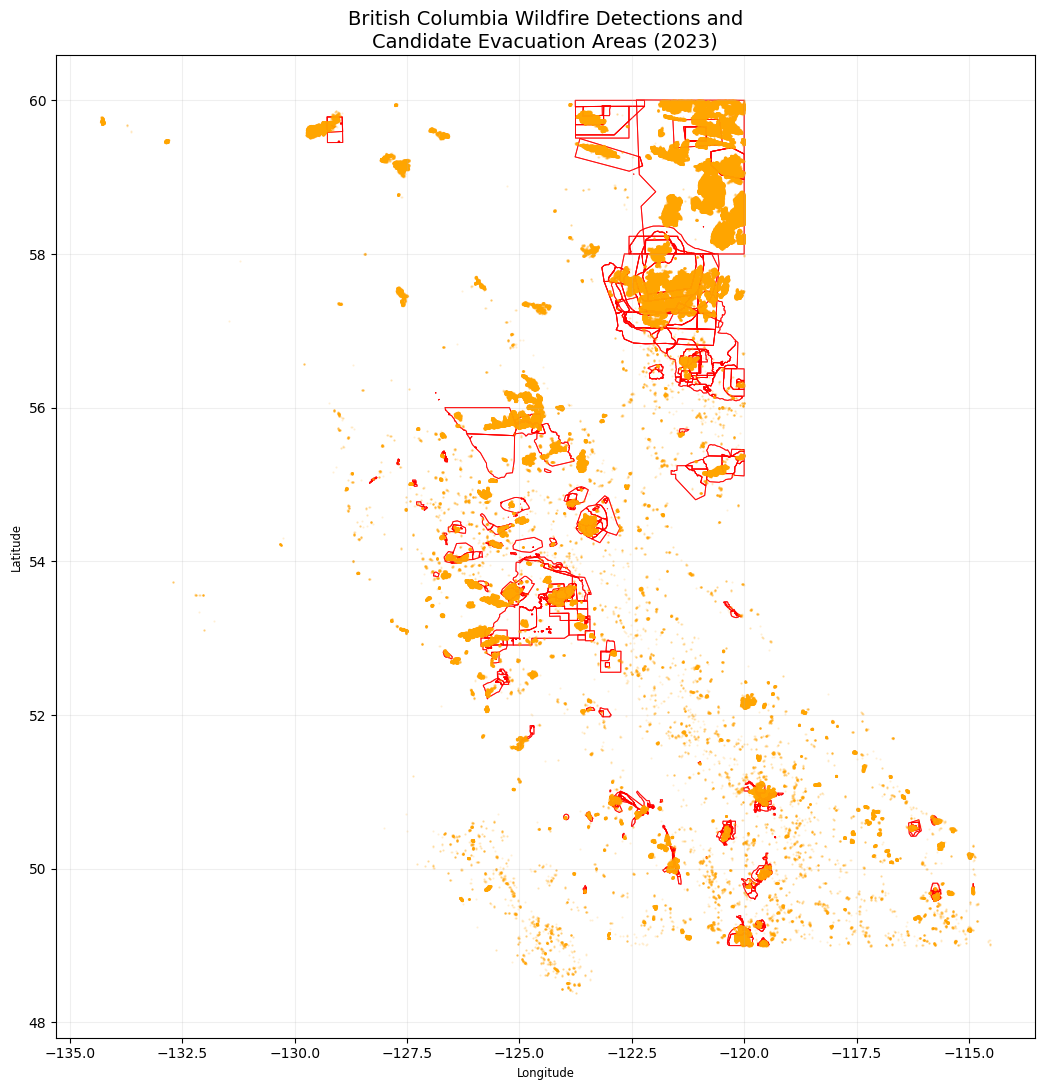

Wildfire detections: 748576
Candidate evacuation records: 1471


In [22]:

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# Convert evacuation polygons from BC Albers
# EPSG:3005 to latitude/longitude EPSG:4326
evac_2023_map = evac_2023.to_crs(epsg=4326)

# Convert NASA FIRMS detections to GeoDataFrame
fires_2023_map = gpd.GeoDataFrame(
    wildfire_df.copy(),
    geometry=gpd.points_from_xy(
        wildfire_df["longitude"],
        wildfire_df["latitude"]
    ),
    crs="EPSG:4326"
)

# Plot both datasets
fig, ax = plt.subplots(figsize=(11, 11))

# Evacuation boundaries
evac_2023_map.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=0.7,
    alpha=0.8,
    label="Evacuation areas"
)

# Wildfire satellite detections
fires_2023_map.plot(
    ax=ax,
    color="orange",
    markersize=0.3,
    alpha=0.15,
    label="NASA FIRMS detections"
)

ax.set_title(
    "British Columbia Wildfire Detections and\n"
    "Candidate Evacuation Areas (2023)",
    fontsize=14
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("Wildfire detections:", len(fires_2023_map))
print("Candidate evacuation records:", len(evac_2023_map))
